In [1]:
from fastai.vision.all import *

In [2]:
torch.cuda.is_available()

True

In [3]:
torch.cuda.get_device_name(0)

'NVIDIA GeForce RTX 3080 Ti'

In [4]:
sampling_frequency = 200 # Hz

In [5]:
import pandas as pd
import numpy as np

from scipy.signal import ShortTimeFFT
from scipy.signal.windows import hamming

def create_spectrograms(df : pd.DataFrame, fault_category : str, SECONDS : int=2, nperseg=None, train_seconds=None, val_seconds=None, test_seconds=None, mode='train'):
    """
    Generates and returns spectrograms for specified time segments.

    Parameters:
    dataDict (dict): Dict containing fault category data.
    fault_category (str): Category to process.
    SECONDS (int): Length of each spectrogram segment in seconds.
    nperseg (int): FFT window size.
    train_seconds (list of tuples): List of (start, end) in seconds for training.
    val_seconds (list of tuples): List of (start, end) in seconds for validation.
    mode (str): 'train' or 'val' - determines which segments to use.

    Returns:
    spectrograms, labels
    """
    all_spectrograms = []
    all_labels = []
    segments = []

    treshold = 3

    peak_time = df[df["sensor_1"] == df["sensor_1"].max()]["time_sec"].max()

    start_time = peak_time - treshold
    end_time = peak_time + treshold
    
    segments.append((start_time, end_time))

    for start_sec, end_sec in segments:
        num_segments = int((end_sec - start_sec) // SECONDS)

        for i in range(num_segments):
            spec_8ch = get_8_channel_spectrogram(
                df[(df["time_sec"] >= start_time) & (df["time_sec"] <= end_time)], nperseg)

            all_spectrograms.append(spec_8ch)
            all_labels.append(fault_category)

            print(f"Generated {i+1} spectrograms - label: {fault_category}")

    return all_spectrograms, all_labels

def get_8_channel_spectrogram(data, sampling_frequency = 200, nperseg = 256):

    all_spectrograms = []

    # Slice to first 5 seconds if desired
    
    for column in data:
        if column.startswith("sensor_1") or column.startswith("sensor_2") or column.startswith("sensor_3") or column.startswith("sensor_4"): # This can be used to filter out specific columns
            
            col = data[column]
            w = hamming(nperseg) # Hamming window
            Sft = ShortTimeFFT(w, hop=int(nperseg*0.25), fs=sampling_frequency, scale_to='psd')
            Sxx = Sft.spectrogram(col.values)  # calculate absolute square of STFT
            all_spectrograms.append(Sxx)

    return np.stack(all_spectrograms, axis=0)

In [6]:
from pathlib import Path

import pandas as pd
import os

def get_data(dir: Path, fault_category: str):
    directory = os.listdir(str(dir))
    
    data = []
    fault_labels = []

    for file in directory:
        if (("Session" in file and "_rel_time" in file)):
            df = pd.DataFrame(pd.read_csv(str(dir/file)))
            spec, labels = create_spectrograms(df, fault_category, SECONDS=3, nperseg=256, train_seconds=[(df["time_sec"].min(), df["time_sec"].max())])
            data += spec
            fault_labels += labels
    
    return data, fault_labels

In [7]:
all_spectograms = []
all_labels = []

In [8]:
hard_falls, hard = get_data(Path('.data/train/hardFall'), "Hard Fall")
all_spectograms += hard_falls
all_labels += hard

Generated 1 spectrograms - label: Hard Fall
Generated 2 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 2 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 2 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 2 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 2 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 2 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 2 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 2 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 2 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 2 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 2 spectrograms - label

In [9]:
controlled_falls, controlled = get_data(Path('.data/train/controlledFall'), 'Controlled Fall')
slip_trip_falls, slip_trip = get_data(Path('.data/train/Slip/Trip'), 'SlipTrip')

all_spectograms += controlled_falls
all_labels += controlled

all_spectograms += slip_trip_falls
all_labels += slip_trip

Generated 1 spectrograms - label: Controlled Fall
Generated 2 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 2 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 2 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 2 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 2 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 2 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 2 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 2 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 2 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 2 spectrograms - label: Controlled Fall


In [10]:
len(all_labels)

293

In [11]:
len(all_spectograms)

293

In [12]:
def split():
    valid_spec = []
    valid_labels = []

    size : int = 30
    
    for i in range(0, size):
        ran_num = random.randint(0, len(all_labels))

        del all_spectograms [ran_num]
        del all_labels [ran_num]

        valid_spec.append(all_spectograms[ran_num])
        valid_labels.append(all_labels[ran_num])
    
    return valid_spec, valid_labels

In [13]:
valid_spec, valid_labels = split()

In [14]:
hard_falls[0].shape

(4, 129, 22)

In [15]:
len(all_spectograms)

263

In [16]:
print(f'Initial shape of a spectrogram: ', all_spectograms[0].shape)

ch, freq_bins, time_bins = all_spectograms[0].shape

ratio = 1800/6400
cutoff_idx = int(freq_bins * ratio) # idx to cut the spectrogram
final_shape = (ch, cutoff_idx, time_bins)
print(f'Final shape: {final_shape}')
print(f'Input Type: {type(all_spectograms[0])}')


Initial shape of a spectrogram:  (4, 129, 22)
Final shape: (4, 36, 22)
Input Type: <class 'numpy.ndarray'>


In [17]:
# constants you can tweak once
FLOOR_DB   = -5.0          # dynamic‑range floor, in dB
TARGET_HW  = (112,112)     # (H, W)
TARGET_CH = 6
EPS = 1e-12
RESIZE_HW  = None

In [18]:
import matplotlib.cm as cm
from matplotlib.colors import Normalize

def create_tensor_image(i : int):
        """
        Convert spectrogram to TensorImage format
        """

        # Normalization - turn spectrogram into dB scale
        arr_db = 10 * np.log10(all_spectograms[i])
        arr_db = np.clip(arr_db, FLOOR_DB, 0)

        # Scale to [0, 1]
        arr_01 = (arr_db - FLOOR_DB) / (-FLOOR_DB)

        # If spectrogram is multi-channel, convert to grayscale first
        if len(arr_01.shape) == 3:
                arr_01 = np.mean(arr_01, axis=-1)  # average across channels
        
        arr_01 = arr_01[:, ::-1].copy() # flip spectrogram
        
        # Apply colormap to convert grayscale to color
        # Popular colormaps for spectrograms: 'viridis', 'plasma', 'magma', 'inferno', 'jet', 'hot'
        colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
        arr_colored = colormap(arr_01)  # This returns RGBA (H, W, 4)
        
        # Convert RGBA to RGB (drop alpha channel)
        arr_rgb = arr_colored[:, :, :3]  # (H, W, 3)
        
        # Convert to PyTorch tensor with correct channel ordering
        t = torch.tensor(arr_rgb).float().permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)
        
        # Resize image
        t_resized = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)
        
        return TensorImage(t_resized.squeeze(0))  # (3, H, W)

/tmp/ipykernel_19713/3571050062.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'


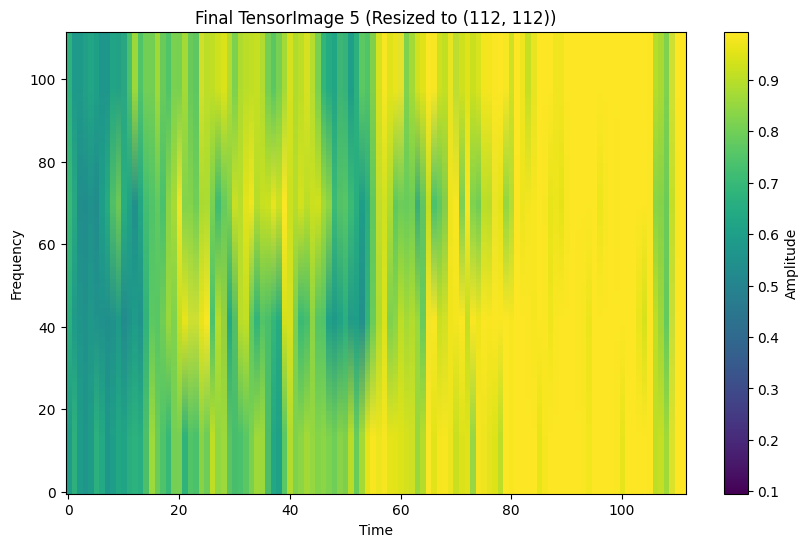

In [19]:
import matplotlib.pyplot as plt

tensor_img = create_tensor_image(5)
    
# Convert back to numpy for plotting
# TensorImage format is (C, H, W)
img_array = tensor_img.numpy()

# Convert from (C, H, W) to (H, W, C) for matplotlib
if img_array.shape[0] == 3:  # RGB
    img_plot = np.transpose(img_array, (1, 2, 0))
else:  # Grayscale
    img_plot = img_array[0]

plt.figure(figsize=(10, 6))
plt.imshow(img_plot, aspect='auto', origin='lower', cmap='viridis')
plt.title(f'Final TensorImage {5} (Resized to {TARGET_HW})')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.colorbar(label='Amplitude')
plt.show()

In [20]:
def get_x(i):
    arr = all_spectograms[i]                 # expected (C, F, T)

    # To tensor; keep size unless RESIZE_HW is set
    t = torch.from_numpy(arr).float().unsqueeze(0)  # (1, C, F, T)
    if TARGET_HW is not None:
        t = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)

    return TensorImage(t.squeeze(0))      # (C, F, T) or (C, H, W) if resized

def get_y(i):
    return all_labels[i]


In [21]:
from pathlib import Path

def build_items(path: Path):
    items = []  # list of (spec_path, label)
    for folder in sorted(os.listdir(path/"train")):
        folder_path = path/"train"/folder
        if not folder_path.is_dir(): 
            continue
        lbl_path = folder_path/"labels.npy"
        if not lbl_path.exists():
            continue

        labels = np.load(lbl_path)
        spec_files = sorted(
            f for f in os.listdir(folder_path)
            if f.endswith(".npy") and f != "labels.npy"
        )

        n = min(len(labels), len(spec_files))
        for f, lab in zip(spec_files[:n], labels[:n]):
            items.append((folder_path/f, lab))
    return items


In [22]:
def time_series_splitter(items):
    n_train = len(all_spectograms)
    return list(range(n_train)), list(range(n_train, len(items)))

In [23]:
block = DataBlock(
    blocks=(TransformBlock(), CategoryBlock(sort=False)),
    get_items=lambda x: x,
    get_x=create_tensor_image,
    get_y=get_y,
)

In [24]:
len(all_spectograms)

263

In [25]:
len(all_labels)

263

In [26]:
items = list(range(len(all_spectograms)))   # or `range(N)`
dls = block.dataloaders(items, bs=16)

/tmp/ipykernel_19713/3571050062.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
/tmp/ipykernel_19713/3571050062.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'


/tmp/ipykernel_19713/3571050062.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'


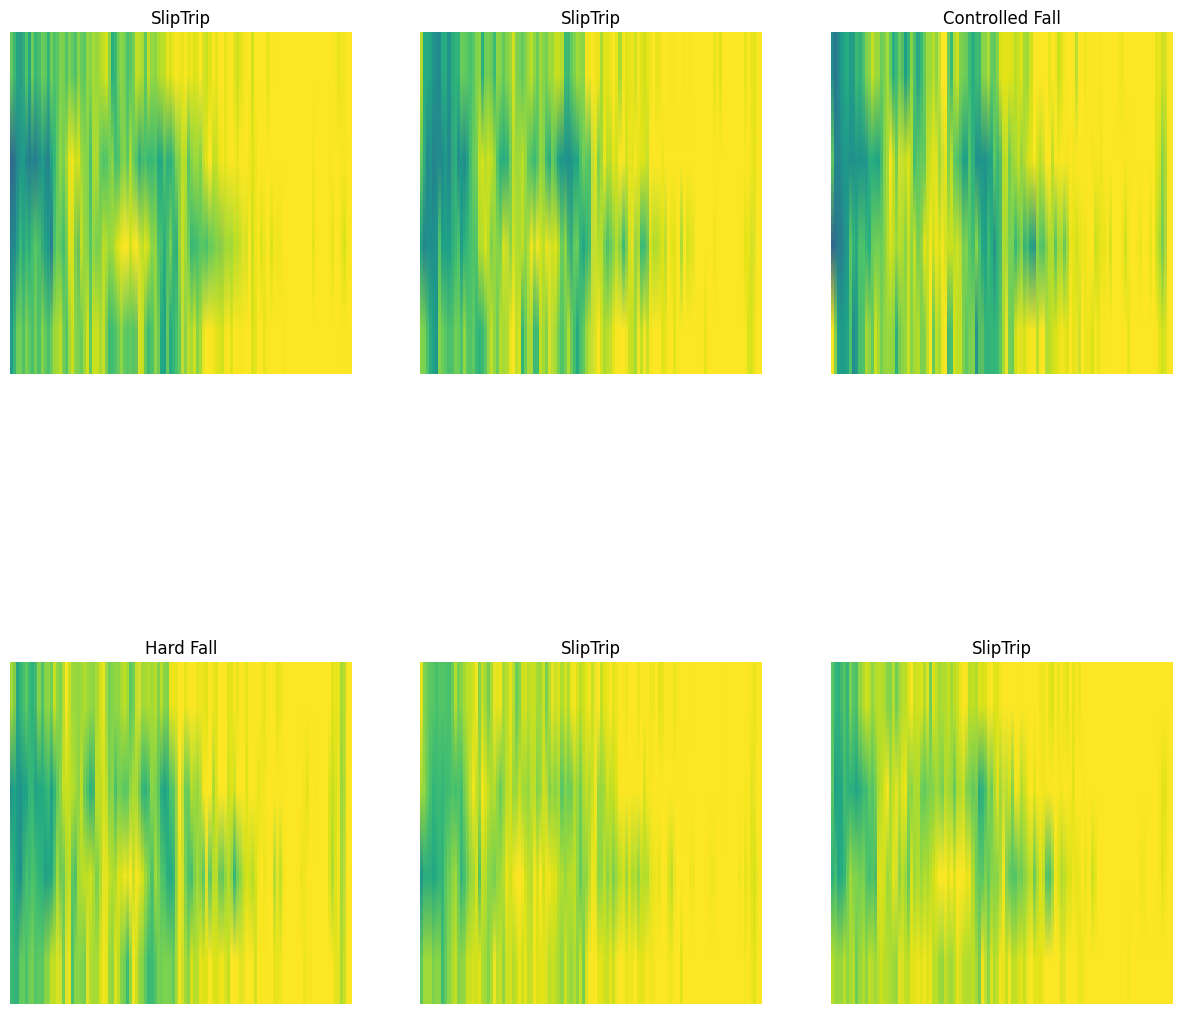

In [27]:
dls.show_batch(max_n=6, figsize=(15,15))

In [28]:
model = nn.Sequential(
    
    nn.Conv2d(3, 8, kernel_size=4, stride=2),     # (8, 55, 55)
    nn.BatchNorm2d(8),
    nn.ReLU(),
            
    nn.Conv2d(8, 16, kernel_size=3, stride=2),     # (16, 27, 27)
    nn.BatchNorm2d(16),
    nn.ReLU(),
        
    nn.Conv2d(16, 32, kernel_size=3, stride=2),    # (32, 13, 13)
    nn.BatchNorm2d(32),
    nn.ReLU(),

    nn.Conv2d(32, 64, kernel_size=3, stride=2),    # (64, 6, 6)
    nn.BatchNorm2d(64),
    nn.ReLU(),

    nn.Flatten(),
    nn.Linear(64*6*6, 14)
)

In [29]:
learner = vision_learner(dls, resnet34, loss_func=CrossEntropyLossFlat(), metrics=accuracy)

In [30]:
learner.summary()

/tmp/ipykernel_19713/3571050062.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'


Sequential (Input shape: 16 x 3 x 112 x 112)
Layer (type)         Output Shape         Param #    Trainable 
                     16 x 64 x 56 x 56   
Conv2d                                    9408       False     
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     16 x 64 x 28 x 28   
MaxPool2d                                                      
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
ReLU                                                           
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
ReLU                      

/tmp/ipykernel_19713/3571050062.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
/tmp/ipykernel_19713/3571050062.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
/tmp/ipykernel_19713/3571050062.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
/tmp

SuggestedLRs(valley=0.0005754399462603033, slide=0.0008317637839354575, steep=0.001737800776027143)

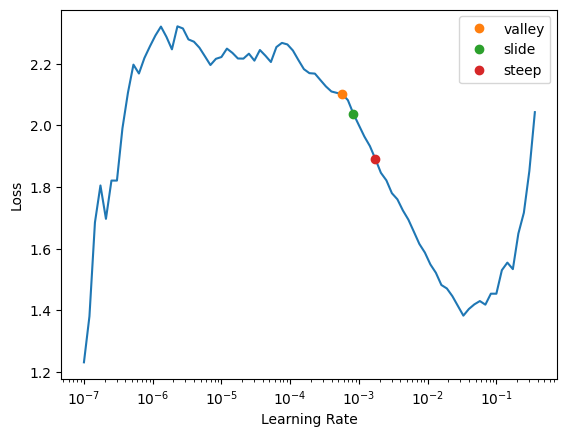

In [31]:
learner.lr_find(suggest_funcs=(valley,slide,steep))

In [32]:
learner.fit_one_cycle(15, 1e-3)

epoch,train_loss,valid_loss,accuracy,time
0,2.032044,1.411898,0.307692,00:00
1,1.595020,0.820748,0.673077,00:00
2,1.282395,0.410607,0.884615,00:00
3,0.963765,0.427095,0.807692,00:00
4,0.734470,0.265221,0.884615,00:00
5,0.559967,0.244432,0.903846,00:00
6,0.448557,0.260254,0.865385,00:00
7,0.374675,0.303018,0.884615,00:00
8,0.291791,0.288343,0.923077,00:00
9,0.246646,0.273504,0.923077,00:00


/tmp/ipykernel_19713/3571050062.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
/tmp/ipykernel_19713/3571050062.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
/tmp/ipykernel_19713/3571050062.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
/tmp

/tmp/ipykernel_19713/3571050062.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
/tmp/ipykernel_19713/3571050062.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
/tmp/ipykernel_19713/3571050062.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
/tmp

/tmp/ipykernel_19713/3571050062.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
/tmp/ipykernel_19713/3571050062.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
/tmp/ipykernel_19713/3571050062.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
/tmp

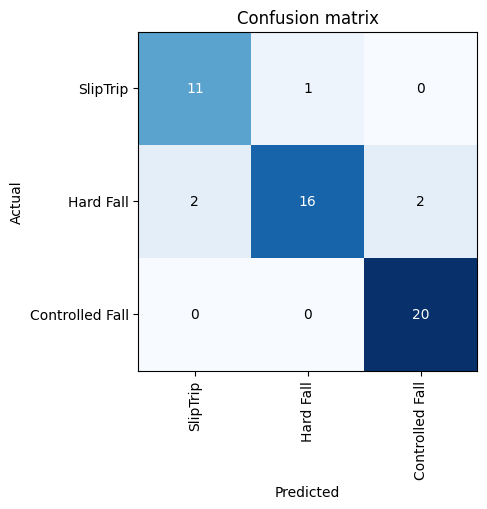

In [40]:
inter_plot = ClassificationInterpretation.from_learner(learner)
inter_plot.plot_confusion_matrix(figsize=(5,5))

/tmp/ipykernel_19713/3571050062.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'


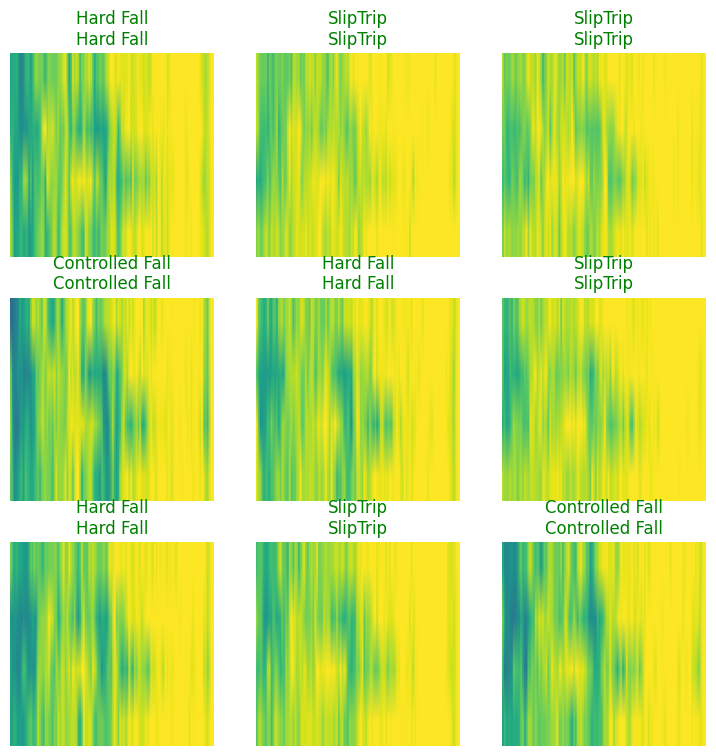

In [41]:
learner.show_results()

In [42]:
def get_x_test(i):
    arr_db = 10 * np.log10(valid_spec[i])
    arr_db = np.clip(arr_db, FLOOR_DB, 0)

    # Scale to [0, 1]
    arr_01 = (arr_db - FLOOR_DB) / (-FLOOR_DB)

    # If spectrogram is multi-channel, convert to grayscale first
    if len(arr_01.shape) == 3:
            arr_01 = np.mean(arr_01, axis=-1)  # average across channels
    
    arr_01 = arr_01[:, ::-1].copy() # flip spectrogram
    
    # Apply colormap to convert grayscale to color
    # Popular colormaps for spectrograms: 'viridis', 'plasma', 'magma', 'inferno', 'jet', 'hot'
    colormap = plt.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
    arr_colored = colormap(arr_01)  # This returns RGBA (H, W, 4)
    
    # Convert RGBA to RGB (drop alpha channel)
    arr_rgb = arr_colored[:, :, :3]  # (H, W, 3)
    
    # Convert to PyTorch tensor with correct channel ordering
    t = torch.tensor(arr_rgb).float().permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)
    
    # Resize image
    t_resized = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)
    
    return TensorImage(t_resized.squeeze(0))  # (3, H, W)


def get_y_test(i):
    return valid_labels[i]

In [48]:
def get_val_accuracy(learner : Learner):

    base = min(len(valid_spec), len(valid_labels))

    true_count = 0

    for i in range(base):
        if learner.predict(get_x_test(i))[0] == get_y_test(i):
            true_count += 1
    
    print(base)

    
    return round((true_count / base), 2)

In [49]:
accuracy = get_val_accuracy(learner)

30


In [51]:
accuracy

0.9

In [52]:
dir = Path('./models')

learner.path = dir

learner.export('classifier.pkl')